# Poverty Map (IWI)

In [ ]:
### IWI (DHS)
### For each houshold: has the following ten assets?
### five consumer durables (TV, fridge, phone, bike, and car)
### access to two public services (water and electricity) 
### three housing characteristics (number of sleeping rooms, quality of floor material and of toilet facility).

## Setup

### Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!ln -s /content/drive/MyDrive/Colab\ Notebooks/SES-Inference /mydrive

Mounted at /content/drive


### Dependencies

In [ ]:
!pip install pyshp

In [3]:
import sys
sys.path.append('/mydrive/libs/')
%set_env PYTHONPATH=/env/python:/mydrive/libs/

%load_ext autoreload
%autoreload 2

from maps.geoviz import GeoViz
from census.dhsmis import DHSMIS
from census.lsms import LSMS
from utils import viz

env: PYTHONPATH=/env/python:/mydrive/libs/


## DHS & MIS IWI
International wealth index (from survey)

source: https://globaldatalab.org/iwi/ 

In [4]:
# Standard DHS
FN_SURVEY_UGANDA_2016 = "/mydrive/data/Uganda/survey/DHS/2016/UGHR7BDT/UGHR7BFL.DTA"      # survey answers per household
FN_SURVEY_UGANDA_SHP_2016 = "/mydrive/data/Uganda/survey/DHS/2016/UGGE7AFL/UGGE7AFL.shp"  # shape (geo) per cluster
FN_SURVEY_UGANDA_DBF_2016 = "/mydrive/data/Uganda/survey/DHS/2016/UGGE7AFL/UGGE7AFL.dbf"  # shape (records) per cluster

# MIS
FN_SURVEY_UGANDA_2018 = "/mydrive/data/Uganda/survey/MIS/2018/UGHR7IDT/UGHR7IFL.DTA"      # survey answers per household
FN_SURVEY_UGANDA_SHP_2018 = "/mydrive/data/Uganda/survey/MIS/2018/UGGE7IFL/UGGE7IFL.shp"  # shape (geo) per cluster
FN_SURVEY_UGANDA_DBF_2018 = "/mydrive/data/Uganda/survey/MIS/2018/UGGE7IFL/UGGE7IFL.dbf"  # shape (records) per cluster

# All data
FN_DATA = {2016:{'survey':FN_SURVEY_UGANDA_2016, 'shp':FN_SURVEY_UGANDA_SHP_2016, 'dbf':FN_SURVEY_UGANDA_DBF_2016},
           2018:{'survey':FN_SURVEY_UGANDA_2018, 'shp':FN_SURVEY_UGANDA_SHP_2018, 'dbf':FN_SURVEY_UGANDA_DBF_2018}}

# Labels
SES_LABELS=['poor','lower_middle','upper_middle','rich']

In [5]:
uganda = DHSMIS()
uganda.load_surveys(FN_DATA, validate=True)
uganda.df_survey.shape, uganda.df_cluster.shape

100%|██████████| 2/2 [00:06<00:00,  3.37s/it]


((27798, 20), (1001, 10))

In [6]:
uganda.df_survey.head()

,year,hhid,hv001,hv002,hv024,hv025,hv270,hv271,hv005,hv208,hv209,hv221,hv243a,hv212,hv210,hv206,hv201,hv213,hv205,hv216
0,2016,00010001,1,1,0,1,5,162975,1.05094e+06,True,True,False,True,False,False,True,11,34,11,2
1,2016,00010002,1,2,0,1,5,177934,1.05094e+06,True,False,False,True,False,False,True,12,34,22,1
2,2016,00010003,1,3,0,1,5,99981,1.05094e+06,False,False,False,True,False,False,False,13,34,22,1
3,2016,00010004,1,4,0,1,5,198741,1.05094e+06,True,True,False,True,False,False,True,14,34,22,4
4,2016,00010005,1,5,0,1,5,100174,1.05094e+06,False,False,False,True,False,False,True,13,34,23,1


In [7]:
uganda.df_cluster.head()

,DHSCC,DHSYEAR,DHSCLUST,URBAN_RURA,LATNUM,LONGNUM,SOURCE,ALT_GPS,ALT_DEM,DATUM
0,UG,2016,1,1,0.320188,32.568206,GPS,9999.0,1197.0,WGS84
1,UG,2016,2,1,0.340653,32.593627,GPS,9999.0,1179.0,WGS84
2,UG,2016,3,1,0.313103,32.566556,GPS,9999.0,1189.0,WGS84
3,UG,2016,4,1,0.353368,32.558144,GPS,9999.0,1181.0,WGS84
4,UG,2016,5,1,0.367388,32.594357,GPS,9999.0,1226.0,WGS84


### Households

In [8]:
uganda.compute_IWI(update_cluster=True)
uganda.df_survey.head()

100%|██████████| 27798/27798 [00:19<00:00, 1462.27it/s]


,year,hhid,hv001,hv002,hv024,hv025,hv270,hv271,hv005,hv208,hv209,hv221,hv243a,hv212,hv210,hv206,hv201,hv213,hv205,hv216,iwi
0,2016,00010001,1,1,0,1,5,162975,1.05094e+06,True,True,False,True,False,False,True,11,34,11,2,73.6
1,2016,00010002,1,2,0,1,5,177934,1.05094e+06,True,False,False,True,False,False,True,12,34,22,1,46.8
2,2016,00010003,1,3,0,1,5,99981,1.05094e+06,False,False,False,True,False,False,False,13,34,22,1,16.3
3,2016,00010004,1,4,0,1,5,198741,1.05094e+06,True,True,False,True,False,False,True,14,34,22,4,42.8
4,2016,00010005,1,5,0,1,5,100174,1.05094e+06,False,False,False,True,False,False,True,13,34,23,1,18.2


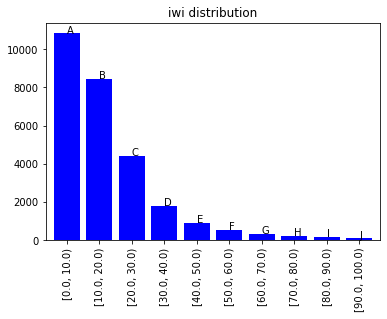

In [9]:
viz.plot_distribution(uganda.df_survey, 'iwi', quantiles=False, nbins=10, ylog=False)

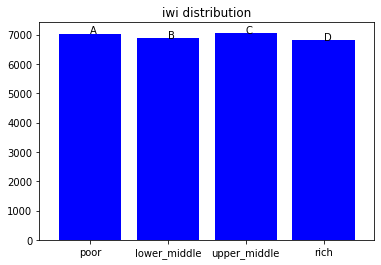

In [10]:
viz.plot_distribution(uganda.df_survey, 'iwi', quantiles=True, nbins=4, labels=SES_LABELS, ylog=False)

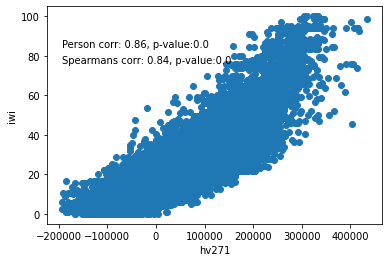

In [11]:
viz.plot_correlation(uganda.df_survey, x='hv271', y='iwi')

### Clusters

In [12]:
uganda.df_cluster.head()

,DHSCC,DHSYEAR,DHSCLUST,URBAN_RURA,LATNUM,LONGNUM,SOURCE,ALT_GPS,ALT_DEM,DATUM,mean_iwi
0,UG,2016,1,1,0.320188,32.568206,GPS,9999.0,1197.0,WGS84,43.300000
1,UG,2016,2,1,0.340653,32.593627,GPS,9999.0,1179.0,WGS84,24.967857
2,UG,2016,3,1,0.313103,32.566556,GPS,9999.0,1189.0,WGS84,34.732000
3,UG,2016,4,1,0.353368,32.558144,GPS,9999.0,1181.0,WGS84,36.060714
4,UG,2016,5,1,0.367388,32.594357,GPS,9999.0,1226.0,WGS84,44.857692


In [13]:
uganda.assign_quantile_based_SES_to_clusters(SES_LABELS)
uganda.df_cluster.head()

,DHSCC,DHSYEAR,DHSCLUST,URBAN_RURA,LATNUM,LONGNUM,SOURCE,ALT_GPS,ALT_DEM,DATUM,mean_iwi,SES
0,UG,2016,1,1,0.320188,32.568206,GPS,9999.0,1197.0,WGS84,43.300000,rich
1,UG,2016,2,1,0.340653,32.593627,GPS,9999.0,1179.0,WGS84,24.967857,rich
2,UG,2016,3,1,0.313103,32.566556,GPS,9999.0,1189.0,WGS84,34.732000,rich
3,UG,2016,4,1,0.353368,32.558144,GPS,9999.0,1181.0,WGS84,36.060714,rich
4,UG,2016,5,1,0.367388,32.594357,GPS,9999.0,1226.0,WGS84,44.857692,rich


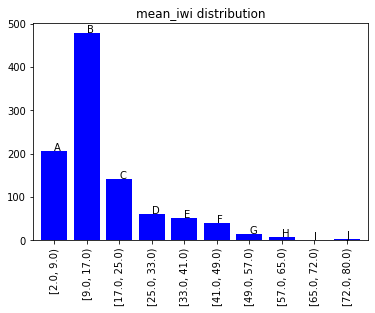

In [20]:
viz.plot_distribution(uganda.df_cluster, 'mean_iwi', quantiles=False, nbins=10, ylog=False)

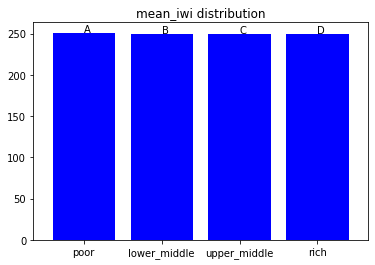

In [21]:
viz.plot_distribution(uganda.df_cluster, 'mean_iwi', quantiles=True, nbins=4, labels=SES_LABELS, ylog=False)